In [34]:
#!unzip -q ~/code/Maelle05/DyslexIA/data/data.zip '*T1*' -d ~/code/Maelle05/DyslexIA/data/data_T1 && rm -rf ~/code/Maelle05/DyslexIA/data/data_T1/__MACOSX

In [46]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

In [36]:
DATA_PATH = "/home/justine/code/Maelle05/DyslexIA/data/data_T1/data"
files = glob.glob(os.path.join(DATA_PATH, "*.csv"))
df_index = pd.DataFrame({"file": files})

In [37]:
def get_type(f):
    if "raw" in f:
        return "raw"
    if "fixations" in f:
        return "fixations"
    if "saccades" in f:
        return "saccades"
    if "metrics" in f:
        return "metrics"
    return "unknown"

def get_subject(f):
    return f.split("Subject_")[1].split("_")[0]

In [39]:
df_index["type"] = df_index["file"].apply(get_type)
df_index["subject"] = df_index["file"].apply(get_subject)
df_index.head()

,file,type,subject
0,/home/justine/code/Maelle05/DyslexIA/data/data...,metrics,1913
1,/home/justine/code/Maelle05/DyslexIA/data/data...,fixations,1257
2,/home/justine/code/Maelle05/DyslexIA/data/data...,metrics,1009
3,/home/justine/code/Maelle05/DyslexIA/data/data...,metrics,1090
4,/home/justine/code/Maelle05/DyslexIA/data/data...,saccades,1398


In [40]:
subject_example = df_index["subject"].iloc[0]
subject_files = df_index[df_index["subject"] == subject_example]

data = {}

for _, row in subject_files.iterrows():
    data[row["type"]] = pd.read_csv(row["file"])

data.keys()

dict_keys(['metrics', 'raw', 'fixations', 'saccades'])

In [41]:
display(data["raw"].head())
#data["raw"].describe()

,time,gaze_x_left,gaze_y_left,gaze_x_right,gaze_y_right,pupil_left,pupil_right,stimfile,subject_id
0,354473473,173.37,161.47,161.54,180.86,4.30,4.17,s7_stimuli_t1.jpg,1913
1,354477468,173.71,161.87,161.93,179.83,4.30,4.17,s7_stimuli_t1.jpg,1913
2,354481464,172.62,161.36,162.12,179.85,4.31,4.17,s7_stimuli_t1.jpg,1913
3,354485459,172.57,159.93,160.99,179.10,4.31,4.16,s7_stimuli_t1.jpg,1913
4,354489455,172.44,159.49,160.86,178.74,4.31,4.16,s7_stimuli_t1.jpg,1913


In [42]:
display(data["fixations"].head())
#data["fixations"].describe()

,id,task,sid,eye,stimfile,trialid,start_ms,end_ms,duration_ms,fix_x,fix_y,orig_fix_x,orig_fix_y,disp_x,disp_y,aoi_subline,aoi_line
0,0,T1_Syllables,1913,b,s7_stimuli_t1.jpg,12,354473.473,354661.396,191.925,161.4425,160.5,161.4425,160.5075,0.422181,0.509473,NaN,NaN
1,1,T1_Syllables,1913,b,s7_stimuli_t1.jpg,12,354741.437,355025.466,288.028,585.4900,160.5,585.4900,348.2425,0.244364,0.929768,line_001-part_003,line_001
2,2,T1_Syllables,1913,b,s7_stimuli_t1.jpg,12,355097.441,355485.458,392.018,351.5650,160.5,351.5650,176.2450,0.276021,1.230305,line_001-part_001,line_001
3,3,T1_Syllables,1913,b,s7_stimuli_t1.jpg,12,355509.461,355765.418,259.956,470.7600,160.5,470.7600,162.8450,0.389446,0.859180,line_001-part_002,line_001
4,4,T1_Syllables,1913,b,s7_stimuli_t1.jpg,12,355893.291,355949.217,59.922,496.6450,160.5,496.6450,159.7500,0.247058,0.698740,line_001-part_002,line_001


Text(0.5, 1.0, 'Distribution des durées de fixations (T1)')

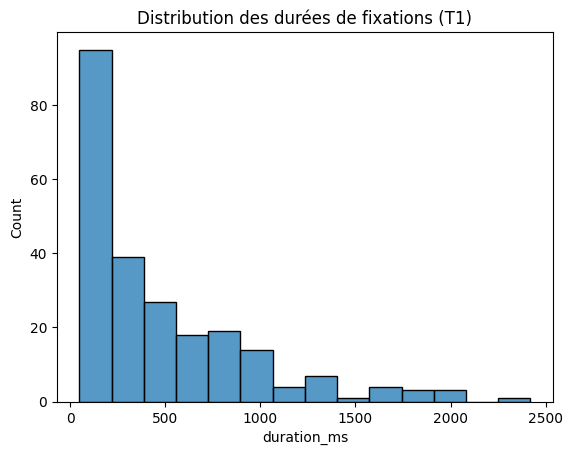

In [45]:
sns.histplot(
    data=data["fixations"],
    x="duration_ms"
)

plt.title("Distribution des durées de fixations (T1)")

In [58]:
fixation_stats = []

for subject in df_index["subject"].unique():
    subject_file = df_index[(df_index["subject"] == subject) & (df_index["type"] == "fixations")]

    df = pd.read_csv(subject_file["file"].iloc[0])
    fixation_stats.append({
        "subject": subject,
        "n_fixations": len(df),
        "mean_duration": df["duration_ms"].mean()
    })

fixation_stats_df = pd.DataFrame(fixation_stats)
fixation_stats_df.head()

,subject,n_fixations,mean_duration
0,1913,235,478.478706
1,1257,202,285.460426
2,1009,192,524.827495
3,1090,143,547.980161
4,1398,156,463.164718


Text(0.5, 1.0, 'Nombre de fixations par sujet (T1)')

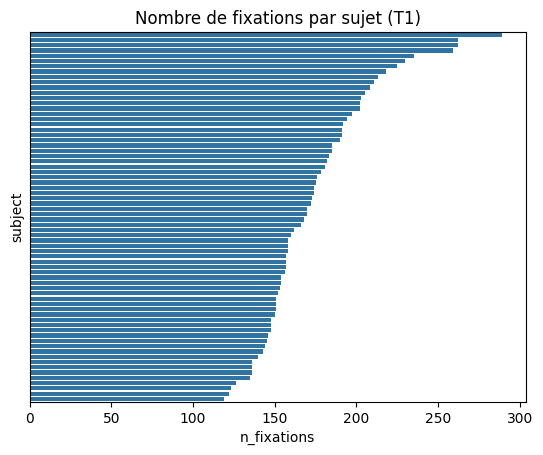

In [62]:
sns.barplot(
    data=fixation_stats_df.sort_values("n_fixations", ascending=False),
    x="n_fixations",
    y="subject",
    orient="h"
)

plt.yticks([])
plt.title("Nombre de fixations par sujet (T1)")

In [47]:
display(data["saccades"].head())
#data["saccades"].describe()

,id,task,sid,eye,stimfile,trialid,start_ms,end_ms,duration_ms,start_x,end_y,start_y,ampl_x,ampl_y,avg_vel_x,avg_vel_y,peak_vel_x,peak_vel_y,end_x,avg_vel,peak_vel,ampl
0,0,T1_Syllables,1913,b,s7_stimuli_t1.jpg,12,354661.396,354741.437,80.041,162.145,321.350,157.475,421.735,163.875,145.056644,53.861768,653.935692,201.413245,583.880,160.981979,654.539231,452.454888
1,1,T1_Syllables,1913,b,s7_stimuli_t1.jpg,12,355025.466,355097.441,71.975,589.040,207.600,351.510,234.895,143.910,85.855603,53.141801,333.035080,255.867816,354.145,109.788679,333.460612,275.473681
2,2,T1_Syllables,1913,b,s7_stimuli_t1.jpg,12,355485.458,355509.461,24.003,352.440,169.320,183.700,113.765,14.380,140.719543,19.136201,424.855404,41.927266,466.205,143.213606,426.187098,114.670221
3,3,T1_Syllables,1913,b,s7_stimuli_t1.jpg,12,355765.418,355893.291,127.873,463.910,175.995,183.325,27.555,7.330,199.595714,85.869090,3154.505310,1350.538229,491.465,218.735156,3431.451188,28.513276
4,4,T1_Syllables,1913,b,s7_stimuli_t1.jpg,12,355949.217,355973.191,23.974,497.570,170.660,161.050,91.280,9.610,112.715745,14.155189,339.111423,20.507321,588.850,117.210187,339.628272,91.784479


Text(0.5, 1.0, 'Distribution des durées de saccades (T1)')

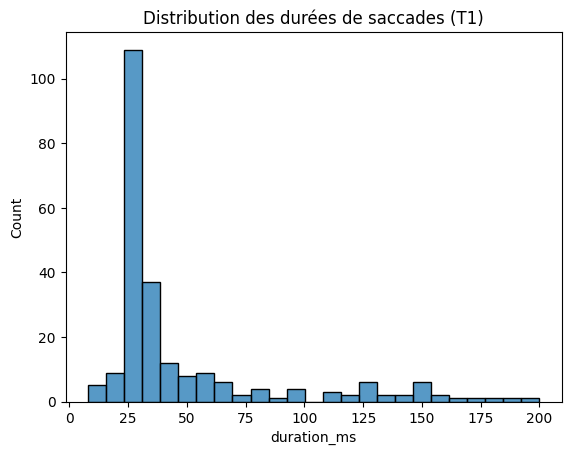

In [64]:
sns.histplot(
    data=data["saccades"],
    x="duration_ms"
)

plt.title("Distribution des durées de saccades (T1)")

In [ ]:
display(data["metrics"].head())
#data["metrics"].describe()

,sid,stimfile,eye_used,trialid,n_fix_trial,sum_fix_dur_trial,dwell_time_trial,mean_fix_dur_trial,n_sacc_trial,sum_sacc_dur_trial,mean_sacc_dur_trial,mean_sacc_ampl_trial,ratio_progress_regress_trial,n_between_line_regress_trial,n_within_line_regress_trial,n_regress_trial,n_progress_trial,n_transit_trial,aoi,aoi_kind,content,dwell_time_aoi,n_fix_aoi,sum_fix_dur_aoi,mean_fix_dur_aoi,skipped_aoi,n_fix_first_visit_aoi,first_fix_dur_aoi,first_fix_land_pos_aoi,dwell_time_first_visit_aoi,sum_fix_dur_first_visit_aoi,sum_fix_dur_after_first_visit_aoi,dwell_time_rereading_aoi,n_revisits_aoi,task
0,1913,s7_stimuli_t1.jpg,b,12,235,112442.496,122453.074,478.478706,234,10950.457,46.796825,116.044769,3.375,0,32,32,108,140,line_001,line,NaN,5031.589,13,9007.588,692.891385,0,13,288.028,0.269117,5031.589,4503.794,0.000,0.000,0,T1_Syllables
1,1913,s7_stimuli_t1.jpg,b,12,235,112442.496,122453.074,478.478706,234,10950.457,46.796825,116.044769,3.375,0,32,32,108,140,line_001-part_001,subline,ma,388.017,1,784.036,784.036000,0,1,392.018,0.699602,388.017,392.018,0.000,0.000,0,T1_Syllables
2,1913,s7_stimuli_t1.jpg,b,12,235,112442.496,122453.074,478.478706,234,10950.457,46.796825,116.044769,3.375,0,32,32,108,140,line_001-part_002,subline,si,439.756,2,639.756,319.878000,0,2,259.956,0.588182,439.756,319.878,0.000,0.000,0,T1_Syllables
3,1913,s7_stimuli_t1.jpg,b,12,235,112442.496,122453.074,478.478706,234,10950.457,46.796825,116.044769,3.375,0,32,32,108,140,line_001-part_003,subline,mu,760.150,3,1464.268,488.089333,0,1,288.028,0.460114,284.029,288.028,444.106,476.121,1,T1_Syllables
4,1913,s7_stimuli_t1.jpg,b,12,235,112442.496,122453.074,478.478706,234,10950.457,46.796825,116.044769,3.375,0,32,32,108,140,line_001-part_004,subline,zu,795.915,2,1559.820,779.910000,0,2,160.031,0.247358,795.915,779.910,0.000,0.000,0,T1_Syllables
